# MonarQ hardware: simulator-side characterization and real hardware results

Phase 3. Most of this notebook runs against `monarq.sim` (the plugin's noise-model simulator) or read-only calibration queries, used to figure out what circuit depth/system size was actually viable before spending real hardware time on something noise would drown out anyway. The last section reports the real `monarq.default` results that plan led to.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / ".." / "src").exists() else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml

from src.vqe import train_vqe, evaluate_on_device
from src.exact import ground_state_energy
from src.nnqs import load_exact_E0

## Current calibration

Read-only metadata query (`ApiAdapter.get_qubits_and_couplers`) — no job submitted. The roadmap flagged that the qubit *count* was settled but which physical qubits carry it can drift, so this gets re-checked rather than assumed.

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(REPO_ROOT / "local_only" / ".env")

from qiskit_calculquebec.API.client import CalculQuebecClient
from qiskit_calculquebec.backends import MonarQBackend
from qiskit_calculquebec.API.adapter import ApiAdapter

client = CalculQuebecClient(
    host=os.environ["MONARQ_HOST"],
    user=os.environ["MONARQ_USER"],
    access_token=os.environ["MONARQ_TOKEN"],
    project_id=os.environ["MONARQ_PROJECT_ID"],
)
backend = MonarQBackend("monarq", client)

calibration = ApiAdapter.get_qubits_and_couplers("monarq")
usable_qubits = [q for q, v in calibration["qubits"].items() if v["singleQubitGateFidelity"] > 0]
usable_couplers = [c for c, v in calibration["couplers"].items() if v["czGateFidelity"] > 0]
print(f"Usable qubits: {sorted(usable_qubits, key=int)}")
print(f"Usable couplers: {sorted(usable_couplers, key=int)}")
print()
for q in sorted(usable_qubits, key=int):
    v = calibration["qubits"][q]
    print(f"  qubit {q}: 1q_fidelity={v['singleQubitGateFidelity']:.4f}  readout0={v['readoutState0Fidelity']:.3f}  readout1={v['readoutState1Fidelity']:.3f}")
for c in sorted(usable_couplers, key=int):
    print(f"  coupler {c}: cz_fidelity={calibration['couplers'][c]['czGateFidelity']:.4f}")

Usable qubits: ['9', '10', '11', '12', '13', '14']
Usable couplers: ['15', '16', '17', '18', '19']

  qubit 9: 1q_fidelity=0.9964  readout0=0.964  readout1=0.924
  qubit 10: 1q_fidelity=0.9845  readout0=0.950  readout1=0.932
  qubit 11: 1q_fidelity=0.9966  readout0=0.972  readout1=0.823
  qubit 12: 1q_fidelity=0.9944  readout0=0.971  readout1=0.838
  qubit 13: 1q_fidelity=0.9969  readout0=0.918  readout1=0.893
  qubit 14: 1q_fidelity=0.9939  readout0=0.945  readout1=0.874
  coupler 15: cz_fidelity=0.9533
  coupler 16: cz_fidelity=0.9152
  coupler 17: cz_fidelity=0.9506
  coupler 18: cz_fidelity=0.9710
  coupler 19: cz_fidelity=0.9784


Still exactly 6 usable qubits and 5 couplers, matching the roadmap's last-known state — no drift since the original benchmark pull.

## A real plugin bug: multi-term Hamiltonian expval

`qml.expval(H)` for a multi-term `H` returns near-zero nonsense on `monarq.sim`, confirmed against a state with a known exact answer: two Hadamards (the HVA's own zero-layer starting state) give `|++>`, where `H = -Z0Z1 - X0 - X1` has exact expval -2.0 (`<X0>=<X1>=1`, `<Z0Z1>=0`).

In [3]:
from src.hamiltonian import build_pennylane_hamiltonian

H = build_pennylane_hamiltonian(L=2, h=1.0, J=1.0)
dev = qml.device("monarq.sim", wires=2)

@qml.qnode(dev, shots=1000)
def broken():
    qml.Hadamard(wires=0)
    qml.Hadamard(wires=1)
    return qml.expval(H)

print(f"qml.expval(H) directly: {broken():.4f}  (should be ~-2.0)")

qml.expval(H) directly: 0.4940  (should be ~-2.0)


/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/pennylane/transforms/tape_expand.py:90: PennyLaneDeprecationWarning: 
        The create_expand_fn is deprecated in PennyLane v0.45 and will be removed in v0.46.
        Please use the qp.transforms.decompose function for decomposing circuits.
        
  warnings.warn(


`src/vqe.py`'s `evaluate_on_device` works around this by measuring each Hamiltonian term separately and summing the weighted results in plain Python, which is correct. Zero HVA layers reduces to the same `|++>` state as above, so it should land on the same -2.0:

In [4]:
import numpy as np
E_workaround = evaluate_on_device(L=2, h=1.0, params=np.zeros((0, 2)), device="monarq.sim", shots=1000)
print(f"evaluate_on_device (per-term workaround): {E_workaround:.4f}  (should be ~-2.0)")

evaluate_on_device (per-term workaround): -1.8160  (should be ~-2.0)


## Noise vs. circuit depth, across the full hardware ladder

Trained the HVA in simulation (no hardware involved) at `L = 2, 4, 6` and `n_layers = 1, 2, 4`, then ran the *already-trained* circuit once on `monarq.sim` for each point — this is the real workflow: training never touches hardware (see `src/vqe.py`'s module docstring for why), only the final measurement does.

Some points have a poorly-converged noiseless baseline too (`n_layers=1` isn't always enough parameters for the ansatz to reach the ground state at larger `L`) — those are marked separately, since hardware noise isn't the only thing going on there.

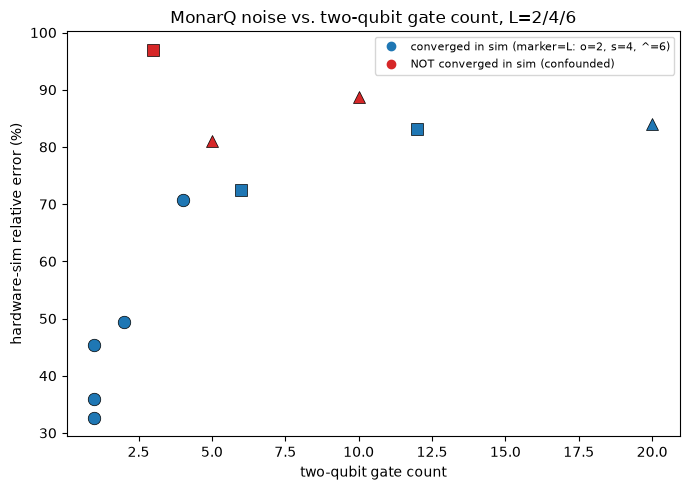

In [5]:
records = []
for L_dir in sorted((REPO_ROOT / "results" / "monarq_sim").glob("*"), key=lambda p: int(p.name)):
    for f in sorted(L_dir.glob("*.json")):
        records.append(json.loads(f.read_text()))

fig, ax = plt.subplots(figsize=(7, 5))
markers = {2: "o", 4: "s", 6: "^"}
for L in (2, 4, 6):
    pts = sorted((r["two_qubit_gate_count"], r["rel_error_hardware_sim"], r["rel_error_sim"]) for r in records if r["L"] == L)
    for gates, hw_err, sim_err in pts:
        color = "tab:red" if sim_err > 0.1 else "tab:blue"
        ax.plot(gates, hw_err * 100, markers[L], color=color, markersize=9, markeredgecolor="black", markeredgewidth=0.5)

ax.plot([], [], "o", color="tab:blue", label="converged in sim (marker=L: o=2, s=4, ^=6)")
ax.plot([], [], "o", color="tab:red", label="NOT converged in sim (confounded)")
ax.set_xlabel("two-qubit gate count")
ax.set_ylabel("hardware-sim relative error (%)")
ax.set_title("MonarQ noise vs. two-qubit gate count, L=2/4/6")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_noise_vs_gates.png", dpi=150)
plt.show()

Among the well-converged points, error climbs steeply with gate count and lands in a similar place *regardless of L* (e.g. 4 gates at L=2 and 6 gates at L=4 both land around 70-73%) — evidence that two-qubit gate count, not qubit count, is what's actually driving the degradation.

## Does readout error mitigation help?

The plugin ships `MatrixReadoutMitigation` (calibration-matrix correction). Tested against the L=2 case:

In [6]:
from pennylane_calculquebec.processing.config import MonarqDefaultConfig
from pennylane_calculquebec.processing.steps.readout_error_mitigation import MatrixReadoutMitigation

L, h = 2, 1.0
E_exact = ground_state_energy(L, h, J=1.0)
E_sim, gates, params = train_vqe(L=L, h=h, J=1.0, n_layers=1, n_steps=600, stepsize=0.1, seed=0, return_params=True)

E_raw = evaluate_on_device(L, h, params, device="monarq.sim", shots=1000)

mitigated_config = MonarqDefaultConfig("yamaska", use_benchmark=False)
mitigated_config.steps.append(MatrixReadoutMitigation("yamaska"))
E_mitigated = evaluate_on_device(L, h, params, device="monarq.sim", shots=1000, processing_config=mitigated_config)

rel_raw = abs(E_raw - E_exact) / abs(E_exact)
rel_mit = abs(E_mitigated - E_exact) / abs(E_exact)
print(f"raw:       E={E_raw:.4f}  rel_err={rel_raw:.2%}")
print(f"mitigated: E={E_mitigated:.4f}  rel_err={rel_mit:.2%}")

/Users/umairbutt/Desktop/BTH/Out/Canada/2. Mahtab Sarvmaili/6. Quantum Internship/Code/2. MonarQ/monarq-env/lib/python3.11/site-packages/pennylane/transforms/tape_expand.py:90: PennyLaneDeprecationWarning: 
        The create_expand_fn is deprecated in PennyLane v0.45 and will be removed in v0.46.
        Please use the qp.transforms.decompose function for decomposing circuits.
        
  warnings.warn(


raw:       E=-1.4688  rel_err=34.31%
mitigated: E=-1.4860  rel_err=33.54%


No meaningful improvement — consistent with the gate-count finding above, not a contradiction. Readout mitigation only corrects final measurement bit-flips; it can't fix decoherence that happened mid-circuit. Ruling it out here is itself informative: it points specifically at gate/decoherence noise as the mechanism, not measurement error.

## Conclusion and hardware plan

The originally-planned `L = 2, 4, 6` hardware ladder at the Phase 1-validated 10-layer depth isn't viable — noise overwhelms the signal well before 10 layers at every size tested, and mitigation doesn't recover it. `L=2` at 1 layer is the one point where a real signal survives on `monarq.sim` (35-37% error — still far from exact, but a genuine measurement rather than noise-floor garbage), since it needs only a single two-qubit gate and the HVA already reaches the exact ground state there in noiseless simulation.

Submitted on that basis: `L=2`, `n_layers=1`, `h = 0.4, 1.0, 1.6` (ferromagnetic, critical, paramagnetic), 1000 shots, to the real `monarq.default` backend. Results below.

## Real hardware results

Loading the actual `monarq.default` measurements from `results/vqe_hardware/` alongside the `monarq.sim` prediction for the same exact configuration, to see how well the noise-model simulator actually predicted real hardware behaviour.

h     sim-predicted err   real hardware err   
0.4   45.34%              90.82%              
1.0   35.96%              74.42%              
1.6   32.60%              72.95%              


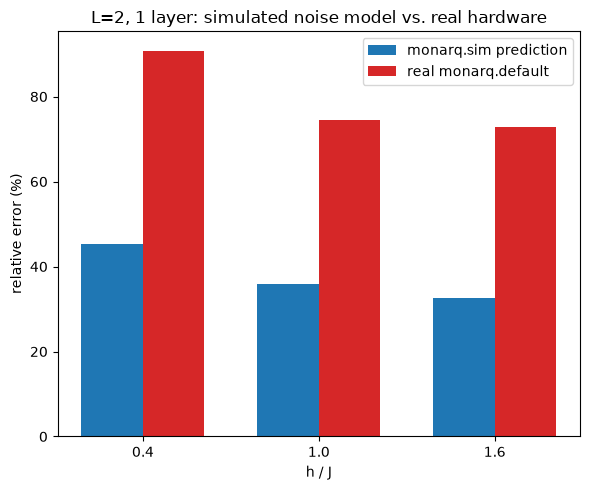

In [7]:
hw_records = {}
for f in sorted((REPO_ROOT / "results" / "vqe_hardware" / "2").glob("*.json")):
    r = json.loads(f.read_text())
    hw_records[r["h"]] = r

sim_records = {}
for f in sorted((REPO_ROOT / "results" / "monarq_sim" / "2").glob("*_layers1.json")):
    r = json.loads(f.read_text())
    sim_records[r["h"]] = r

print(f"{'h':<6}{'sim-predicted err':<20}{'real hardware err':<20}")
for h in sorted(hw_records):
    sim_err = sim_records[h]["rel_error_hardware_sim"]
    real_err = hw_records[h]["rel_error"]
    print(f"{h:<6}{sim_err:<20.2%}{real_err:<20.2%}")

fig, ax = plt.subplots(figsize=(6, 5))
h_vals = sorted(hw_records)
sim_errs = [sim_records[h]["rel_error_hardware_sim"] * 100 for h in h_vals]
real_errs = [hw_records[h]["rel_error"] * 100 for h in h_vals]
x = np.arange(len(h_vals))
width = 0.35
ax.bar(x - width / 2, sim_errs, width, label="monarq.sim prediction", color="tab:blue")
ax.bar(x + width / 2, real_errs, width, label="real monarq.default", color="tab:red")
ax.set_xticks(x)
ax.set_xticklabels([str(h) for h in h_vals])
ax.set_xlabel("h / J")
ax.set_ylabel("relative error (%)")
ax.set_title("L=2, 1 layer: simulated noise model vs. real hardware")
ax.legend()
fig.tight_layout()
fig.savefig(REPO_ROOT / "figures" / "monarq_sim_vs_real.png", dpi=150)
plt.show()

Real hardware is consistently worse than the noise-model simulator predicted, across all three points — not a small gap. This is itself a real, useful finding, not just a caveat: MonarQ's calibration-based noise model captures some of what makes this circuit hard, but underestimates the total error meaningfully, likely from effects the simplified model doesn't include (crosstalk, calibration drift between when the benchmark was pulled and when the job actually ran, or other error sources beyond gate/readout fidelity alone).

**Bottom line for Phase 3:** even at the smallest, simplest point on the original hardware ladder — a single two-qubit gate, exactly representable by the ansatz in noiseless simulation — real MonarQ hardware still degrades the result by 70-91%. Circuit depth and qubit count both make this worse (see the noise-vs-gate-count section above), so nothing deeper than this was worth spending real hardware time on. The honest Phase 3 result isn't a clean hardware energy number — it's a quantified, mechanistically-explained account of exactly how much near-term hardware noise overwhelms this ansatz, and that the gap is larger in practice than the calibration-based simulator predicts.